In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Define the stocks and their Yahoo Finance ticker symbols
stocks = {
    "HDFC Bank": "HDFCBANK.NS",
    "Reliance Industries": "RELIANCE.NS",
    "TCS": "TCS.NS",
    "Mahindra & Mahindra": "M&M.NS",
    "Adani Enterprises": "ADANIENT.NS",
    "JSW Steel": "JSWSTEEL.NS",
    "Sun Pharma": "SUNPHARMA.NS",
    "Bharti Airtel": "BHARTIARTL.NS",
    "Larsen & Toubro": "LT.NS",
    "Bajaj Finance": "BAJFINANCE.NS"
}

# Define Nifty 50 as the market benchmark
benchmark = {
    "Nifty 50": "^NSEI"
}

# Define the historical data period
start_date = "2021-01-01"
end_date = "2026-01-01"

# Display the selected assets and analysis period
print("Stocks:", stocks)
print("Benchmark:", benchmark)
print("Period:", start_date, "to", end_date)

Stocks: {'HDFC Bank': 'HDFCBANK.NS', 'Reliance Industries': 'RELIANCE.NS', 'TCS': 'TCS.NS', 'Mahindra & Mahindra': 'M&M.NS', 'Adani Enterprises': 'ADANIENT.NS', 'JSW Steel': 'JSWSTEEL.NS', 'Sun Pharma': 'SUNPHARMA.NS', 'Bharti Airtel': 'BHARTIARTL.NS', 'Larsen & Toubro': 'LT.NS', 'Bajaj Finance': 'BAJFINANCE.NS'}
Benchmark: {'Nifty 50': '^NSEI'}
Period: 2021-01-01 to 2026-01-01


In [ ]:
# Download historical price data for all selected stocks
stock_data = yf.download(
    list(stocks.values()),
    start=start_date,
    end=end_date,
    auto_adjust=True
)

# Download historical data for Nifty 50 benchmark
nifty_data = yf.download(
    benchmark["Nifty 50"],
    start=start_date,
    end=end_date,
    auto_adjust=True
)

# Display the first 5 rows of stock data
print("Stock Data:")
print(stock_data.head())

# Display the first 5 rows of Nifty 50 data
print("\nNifty 50 Data:")
print(nifty_data.head())

[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  1 of 1 completed

Stock Data:
Price            Close                                                      \
Ticker     ADANIENT.NS BAJFINANCE.NS BHARTIARTL.NS HDFCBANK.NS JSWSTEEL.NS   
Date                                                                         
2021-01-01  489.740906    514.063965    488.065765  663.905640  366.791260   
2021-01-04  493.081268    507.838074    489.913239  659.689453  379.403534   
2021-01-05  492.981567    498.374878    486.976196  664.674377  372.014984   
2021-01-06  489.491608    489.739227    497.682098  661.809143  378.085785   
2021-01-07  516.613525    494.675293    516.583252  659.805847  381.568329   

Price                                                                      \
Ticker            LT.NS      M&M.NS RELIANCE.NS SUNPHARMA.NS       TCS.NS   
Date                                                                        
2021-01-01  1218.873169  691.493164  897.047119   561.122314  2521.073975   
2021-01-04  1235.413086  707.212158  898.559082   568.7

In [ ]:
# Check the size of the downloaded stock dataset
print("Dataset Shape:", stock_data.shape)

# Check the first and last available trading dates
print("\nStart Date:", stock_data.index.min())
print("End Date:", stock_data.index.max())

# Check the number of missing values in the dataset
print("\nMissing Values:")
print(stock_data.isna().sum())

# Check the number of duplicate dates
print("\nDuplicate Dates:", stock_data.index.duplicated().sum())

Dataset Shape: (1236, 50)

Start Date: 2021-01-01 00:00:00
End Date: 2025-12-31 00:00:00

Missing Values:
Price   Ticker       
Close   ADANIENT.NS      0
        BAJFINANCE.NS    0
        BHARTIARTL.NS    0
        HDFCBANK.NS      0
        JSWSTEEL.NS      0
        LT.NS            0
        M&M.NS           0
        RELIANCE.NS      0
        SUNPHARMA.NS     0
        TCS.NS           0
High    ADANIENT.NS      0
        BAJFINANCE.NS    0
        BHARTIARTL.NS    0
        HDFCBANK.NS      0
        JSWSTEEL.NS      0
        LT.NS            0
        M&M.NS           0
        RELIANCE.NS      0
        SUNPHARMA.NS     0
        TCS.NS           0
Low     ADANIENT.NS      0
        BAJFINANCE.NS    0
        BHARTIARTL.NS    0
        HDFCBANK.NS      0
        JSWSTEEL.NS      0
        LT.NS            0
        M&M.NS           0
        RELIANCE.NS      0
        SUNPHARMA.NS     0
        TCS.NS           0
Open    ADANIENT.NS      0
        BAJFINANCE.NS    0
        

In [ ]:
# Extract the Nifty 50 closing prices
nifty_prices = nifty_data["Close"]

# Convert the Nifty 50 data from DataFrame to Series
nifty_prices = nifty_prices.squeeze()

# Give the benchmark series a clear name
nifty_prices.name = "Nifty 50"

# Display the first 5 observations
print(nifty_prices.head())

# Check the number of observations
print("\nNumber of Nifty 50 observations:", len(nifty_prices))

# Check for missing values
print("\nMissing Values:", nifty_prices.isna().sum())

# Check for duplicate dates
print("Duplicate Dates:", nifty_prices.index.duplicated().sum())

Date
2021-01-01    14018.500000
2021-01-04    14132.900391
2021-01-05    14199.500000
2021-01-06    14146.250000
2021-01-07    14137.349609
Name: Nifty 50, dtype: float64

Number of Nifty 50 observations: 1236

Missing Values: 0
Duplicate Dates: 0


In [ ]:

# Extract stock closing prices
prices = stock_data["Close"]

# Combine stock prices and Nifty 50 prices
prices_with_nifty = prices.join(nifty_prices, how="inner")

# Display the first 5 rows
print(prices_with_nifty.head())

# Check the shape of the combined dataset
print("\nCombined Dataset Shape:", prices_with_nifty.shape)

# Check for missing values after combining the datasets
print("\nMissing Values:")
print(prices_with_nifty.isna().sum())

# Check the date range of the combined dataset
print("\nStart Date:", prices_with_nifty.index.min())
print("End Date:", prices_with_nifty.index.max())

            ADANIENT.NS  BAJFINANCE.NS  BHARTIARTL.NS  HDFCBANK.NS  \
Date                                                                 
2021-01-01   489.740906     514.063965     488.065765   663.905640   
2021-01-04   493.081268     507.838074     489.913239   659.689453   
2021-01-05   492.981567     498.374878     486.976196   664.674377   
2021-01-06   489.491608     489.739227     497.682098   661.809143   
2021-01-07   516.613525     494.675293     516.583252   659.805847   

            JSWSTEEL.NS        LT.NS      M&M.NS  RELIANCE.NS  SUNPHARMA.NS  \
Date                                                                          
2021-01-01   366.791260  1218.873169  691.493164   897.047119    561.122314   
2021-01-04   379.403534  1235.413086  707.212158   898.559082    568.792053   
2021-01-05   372.014984  1227.613037  698.715332   887.388306    567.898132   
2021-01-06   378.085785  1234.849121  694.939026   863.986023    569.638977   
2021-01-07   381.568329  1258.29626

In [ ]:
# Calculate daily percentage returns for all stocks and Nifty 50
daily_returns = prices_with_nifty.pct_change()

# Remove the first row because it has no previous trading day
daily_returns = daily_returns.dropna()

# Display the first 5 daily returns
print(daily_returns.head())

# Check the size of the returns dataset
print("\nReturns Dataset Shape:", daily_returns.shape)

            ADANIENT.NS  BAJFINANCE.NS  BHARTIARTL.NS  HDFCBANK.NS  \
Date                                                                 
2021-01-04     0.006821      -0.012111       0.003785    -0.006351   
2021-01-05    -0.000202      -0.018634      -0.005995     0.007556   
2021-01-06    -0.007079      -0.017328       0.021984    -0.004311   
2021-01-07     0.055408       0.010079       0.037978    -0.003027   
2021-01-08    -0.000193       0.000197      -0.009170     0.010874   

            JSWSTEEL.NS     LT.NS    M&M.NS  RELIANCE.NS  SUNPHARMA.NS  \
Date                                                                     
2021-01-04     0.034385  0.013570  0.022732     0.001685      0.013669   
2021-01-05    -0.019474 -0.006314 -0.012015    -0.012432     -0.001572   
2021-01-06     0.016319  0.005894 -0.005405    -0.026372      0.003065   
2021-01-07     0.009211  0.018988  0.011276    -0.001619     -0.005617   
2021-01-08    -0.006290  0.025729  0.035062     0.011799      0.0

In [ ]:
# Calculate the average daily return for each stock and Nifty 50
average_daily_return = daily_returns.mean()

# Convert returns from decimal form to percentage form
average_daily_return_pct = average_daily_return * 100

# Display the average daily returns
print("Average Daily Returns:")
print(average_daily_return_pct.round(4))

Average Daily Returns:
ADANIENT.NS      0.1736
BAJFINANCE.NS    0.0686
BHARTIARTL.NS    0.1276
HDFCBANK.NS      0.0401
JSWSTEEL.NS      0.1107
LT.NS            0.1087
M&M.NS           0.1513
RELIANCE.NS      0.0552
SUNPHARMA.NS     0.0986
TCS.NS           0.0250
Nifty 50         0.0543
dtype: float64


In [ ]:
# Calculate the total number of years in the dataset
years = (
    prices_with_nifty.index[-1] - prices_with_nifty.index[0]
).days / 365.25

# Calculate annualized return using CAGR
annualized_return = (
    (prices_with_nifty.iloc[-1] / prices_with_nifty.iloc[0]) ** (1 / years)
) - 1

# Convert returns to percentage form
annualized_return_pct = annualized_return * 100

# Display annualized returns
print("Annualized Returns (%):")
print(annualized_return_pct.round(2))

Annualized Returns (%):
ADANIENT.NS      35.55
BAJFINANCE.NS    13.80
BHARTIARTL.NS    33.65
HDFCBANK.NS       8.00
JSWSTEEL.NS      25.87
LT.NS            27.13
M&M.NS           39.67
RELIANCE.NS      11.76
SUNPHARMA.NS     24.90
TCS.NS            4.16
Nifty 50         13.27
dtype: float64


In [ ]:
# Calculate the standard deviation of daily returns for each stock
daily_volatility = daily_returns.std()

# Convert volatility from decimal form to percentage form
daily_volatility_pct = daily_volatility * 100

# Display daily volatility
print("Daily Volatility (%):")
print(daily_volatility_pct.round(4))

Daily Volatility (%):
ADANIENT.NS      3.1371
BAJFINANCE.NS    1.8063
BHARTIARTL.NS    1.4300
HDFCBANK.NS      1.3377
JSWSTEEL.NS      1.8708
LT.NS            1.5166
M&M.NS           1.7930
RELIANCE.NS      1.4320
SUNPHARMA.NS     1.3185
TCS.NS           1.3075
Nifty 50         0.8811
dtype: float64


In [ ]:
# Annualize daily volatility using approximately 252 trading days per year
annualized_volatility = daily_volatility * np.sqrt(252)

# Convert annualized volatility from decimal form to percentage form
annualized_volatility_pct = annualized_volatility * 100

# Display annualized volatility
print("Annualized Volatility (%):")
print(annualized_volatility_pct.round(2))

Annualized Volatility (%):
ADANIENT.NS      49.80
BAJFINANCE.NS    28.67
BHARTIARTL.NS    22.70
HDFCBANK.NS      21.24
JSWSTEEL.NS      29.70
LT.NS            24.08
M&M.NS           28.46
RELIANCE.NS      22.73
SUNPHARMA.NS     20.93
TCS.NS           20.76
Nifty 50         13.99
dtype: float64


In [ ]:
# Calculate the running maximum price reached by each asset
running_max = prices_with_nifty.cummax()

# Calculate the percentage decline from each running maximum
drawdown = (prices_with_nifty / running_max) - 1

# Find the maximum drawdown for each asset
maximum_drawdown = drawdown.min()

# Convert drawdown from decimal form to percentage form
maximum_drawdown_pct = maximum_drawdown * 100

# Display maximum drawdown
print("Maximum Drawdown (%):")
print(maximum_drawdown_pct.round(2))

Maximum Drawdown (%):
ADANIENT.NS     -71.35
BAJFINANCE.NS   -33.36
BHARTIARTL.NS   -17.37
HDFCBANK.NS     -23.24
JSWSTEEL.NS     -31.18
LT.NS           -28.88
M&M.NS          -28.09
RELIANCE.NS     -27.18
SUNPHARMA.NS    -19.13
TCS.NS          -34.45
Nifty 50        -17.23
dtype: float64


In [ ]:
# Set the assumed annual risk-free rate
risk_free_rate = 0.06

# Calculate the excess annual return over the risk-free rate
excess_return = annualized_return - risk_free_rate

# Calculate the Sharpe ratio using annualized volatility
sharpe_ratio = excess_return / annualized_volatility

# Display the Sharpe ratio
print("Sharpe Ratio:")
print(sharpe_ratio.round(2))

Sharpe Ratio:
ADANIENT.NS      0.59
BAJFINANCE.NS    0.27
BHARTIARTL.NS    1.22
HDFCBANK.NS      0.09
JSWSTEEL.NS      0.67
LT.NS            0.88
M&M.NS           1.18
RELIANCE.NS      0.25
SUNPHARMA.NS     0.90
TCS.NS          -0.09
Nifty 50         0.52
dtype: float64


In [ ]:
# Import the OLS regression function
import statsmodels.api as sm

# Separate Nifty 50 returns as the market return
market_returns = daily_returns["Nifty 50"]

# Create a dictionary to store regression results
capm_results = {}

# Run CAPM regression for each stock
for stock in stocks.values():

    # Select the stock's daily returns
    stock_returns = daily_returns[stock]

    # Calculate excess returns over the risk-free rate
    # Here we temporarily use 6% annual risk-free rate
    daily_rf = (1 + 0.06) ** (1 / 252) - 1

    excess_stock_return = stock_returns - daily_rf
    excess_market_return = market_returns - daily_rf

    # Add a constant term to estimate Alpha
    X = sm.add_constant(excess_market_return)

    # Run OLS regression
    model = sm.OLS(excess_stock_return, X).fit()

    # Store the regression model
    capm_results[stock] = model

# Display the regression summary for the first stock
first_stock = list(stocks.values())[0]
print(capm_results[first_stock].summary())

                            OLS Regression Results                            
Dep. Variable:            HDFCBANK.NS   R-squared:                       0.482
Model:                            OLS   Adj. R-squared:                  0.481
Method:                 Least Squares   F-statistic:                     1145.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):          4.39e-178
Time:                        15:53:54   Log-Likelihood:                 3981.8
No. Observations:                1235   AIC:                            -7960.
Df Residuals:                    1233   BIC:                            -7949.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.000     -0.580      0.5

In [ ]:
# Create an empty list to store CAPM results
capm_summary = []

# Extract important regression statistics for each stock
for stock in stocks.values():

    # Get the regression model for the stock
    model = capm_results[stock]

    # Store the key CAPM statistics
    capm_summary.append({
        "Stock": stock,
        "Alpha": model.params["const"],
        "Beta": model.params["Nifty 50"],
        "R_Squared": model.rsquared,
        "Beta_P_Value": model.pvalues["Nifty 50"],
        "Alpha_P_Value": model.pvalues["const"]
    })

# Convert the results into a DataFrame
capm_table = pd.DataFrame(capm_summary)

# Display the CAPM results
print(capm_table.round(4))

           Stock   Alpha    Beta  R_Squared  Beta_P_Value  Alpha_P_Value
0    HDFCBANK.NS -0.0002  1.0535     0.4815           0.0         0.5618
1    RELIANCE.NS -0.0000  1.1216     0.4762           0.0         0.9217
2         TCS.NS -0.0002  0.7850     0.2799           0.0         0.4746
3         M&M.NS  0.0009  1.1461     0.3172           0.0         0.0288
4    ADANIENT.NS  0.0010  1.6696     0.2199           0.0         0.2126
5    JSWSTEEL.NS  0.0005  1.2199     0.3301           0.0         0.2567
6   SUNPHARMA.NS  0.0006  0.6039     0.1629           0.0         0.0994
7  BHARTIARTL.NS  0.0008  0.8248     0.2583           0.0         0.0249
8          LT.NS  0.0005  1.1302     0.4312           0.0         0.1230
9  BAJFINANCE.NS  0.0001  1.2540     0.3742           0.0         0.8761


In [ ]:
# Create equal weights for the 10 stocks
number_of_stocks = len(stocks)
equal_weight = 1 / number_of_stocks

# Create a weight dictionary with 10% allocated to each stock
weights = {
    stock: equal_weight
    for stock in stocks.values()
}

# Display the portfolio weights
print("Equal-Weight Portfolio:")
for stock, weight in weights.items():
    print(stock, ":", round(weight * 100, 2), "%")

# Calculate the portfolio's daily return
portfolio_daily_returns = (
    daily_returns[list(stocks.values())] * equal_weight
).sum(axis=1)

# Display the first 5 portfolio returns
print("\nFirst 5 Portfolio Daily Returns:")
print(portfolio_daily_returns.head())

Equal-Weight Portfolio:
HDFCBANK.NS : 10.0 %
RELIANCE.NS : 10.0 %
TCS.NS : 10.0 %
M&M.NS : 10.0 %
ADANIENT.NS : 10.0 %
JSWSTEEL.NS : 10.0 %
SUNPHARMA.NS : 10.0 %
BHARTIARTL.NS : 10.0 %
LT.NS : 10.0 %
BAJFINANCE.NS : 10.0 %

First 5 Portfolio Daily Returns:
Date
2021-01-04    0.011616
2021-01-05   -0.005146
2021-01-06   -0.002665
2021-01-07    0.012655
2021-01-08    0.012846
dtype: float64


In [ ]:
# Calculate the number of years in our investment period
portfolio_years = (
    portfolio_daily_returns.index[-1] -
    portfolio_daily_returns.index[0]
).days / 365.25

# Calculate the cumulative growth of the portfolio
cumulative_growth = (1 + portfolio_daily_returns).prod()

# Calculate the annualized portfolio return (CAGR)
portfolio_annualized_return = (cumulative_growth ** (1 / portfolio_years)) - 1

# Convert the return into percentage form
portfolio_annualized_return_pct = portfolio_annualized_return * 100

# Display the annualized portfolio return
print("Portfolio Annualized Return (%):")
print(round(portfolio_annualized_return_pct, 2))

Portfolio Annualized Return (%):
25.12


In [ ]:
# Calculate the portfolio's daily volatility
portfolio_daily_volatility = portfolio_daily_returns.std()

# Annualize the portfolio volatility
portfolio_annualized_volatility = (
    portfolio_daily_volatility * np.sqrt(252)
)

# Convert volatility into percentage form
portfolio_annualized_volatility_pct = (
    portfolio_annualized_volatility * 100
)

# Display the portfolio's annualized volatility
print("Portfolio Annualized Volatility (%):")
print(round(portfolio_annualized_volatility_pct, 2))

Portfolio Annualized Volatility (%):
16.44


In [ ]:
# Calculate the cumulative value of the portfolio
portfolio_growth = (1 + portfolio_daily_returns).cumprod()

# Find the highest portfolio value reached up to each date
portfolio_running_max = portfolio_growth.cummax()

# Calculate the portfolio drawdown from its previous peak
portfolio_drawdown = (
    portfolio_growth / portfolio_running_max
) - 1

# Find the worst drawdown during the entire period
portfolio_max_drawdown = portfolio_drawdown.min()

# Convert to percentage form
portfolio_max_drawdown_pct = portfolio_max_drawdown * 100

# Display the portfolio maximum drawdown
print("Portfolio Maximum Drawdown (%):")
print(round(portfolio_max_drawdown_pct, 2))

Portfolio Maximum Drawdown (%):
-14.73


In [ ]:
# Set the assumed annual risk-free rate
risk_free_rate = 0.06

# Calculate the portfolio's excess return over the risk-free rate
portfolio_excess_return = (
    portfolio_annualized_return - risk_free_rate
)

# Calculate the portfolio Sharpe ratio
portfolio_sharpe_ratio = (
    portfolio_excess_return /
    portfolio_annualized_volatility
)

# Display the portfolio Sharpe ratio
print("Portfolio Sharpe Ratio:")
print(round(portfolio_sharpe_ratio, 2))

Portfolio Sharpe Ratio:
1.16


In [ ]:
# Calculate daily excess returns for the portfolio
portfolio_excess_returns = (
    portfolio_daily_returns - daily_rf
)

# Calculate daily excess returns for the Nifty 50
market_excess_returns = (
    market_returns - daily_rf
)

# Add a constant term to estimate portfolio Alpha
X_portfolio = sm.add_constant(market_excess_returns)

# Run OLS regression for the portfolio
portfolio_capm = sm.OLS(
    portfolio_excess_returns,
    X_portfolio
).fit()

# Extract portfolio Alpha and Beta
portfolio_alpha = portfolio_capm.params["const"]
portfolio_beta = portfolio_capm.params["Nifty 50"]

# Display portfolio Alpha and Beta
print("Portfolio Alpha:", round(portfolio_alpha, 6))
print("Portfolio Beta:", round(portfolio_beta, 4))

# Display the R-squared value
print("Portfolio R-Squared:", round(portfolio_capm.rsquared, 4))

Portfolio Alpha: 0.000391
Portfolio Beta: 1.0808
Portfolio R-Squared: 0.8459


In [ ]:
# Calculate the portfolio's excess return over the risk-free rate
portfolio_excess_return = (
    portfolio_annualized_return - risk_free_rate
)

# Calculate the Treynor ratio using portfolio Beta
portfolio_treynor_ratio = (
    portfolio_excess_return / portfolio_beta
)

# Display the portfolio Treynor ratio
print("Portfolio Treynor Ratio:")
print(round(portfolio_treynor_ratio, 4))

Portfolio Treynor Ratio:
0.1769


In [ ]:
# Select only the 10 stocks and exclude Nifty 50
stock_returns = daily_returns[list(stocks.values())]

# Calculate the correlation matrix
correlation_matrix = stock_returns.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix.round(2))


Correlation Matrix:
               HDFCBANK.NS  RELIANCE.NS  TCS.NS  M&M.NS  ADANIENT.NS  \
HDFCBANK.NS           1.00         0.36    0.23    0.33         0.27   
RELIANCE.NS           0.36         1.00    0.29    0.34         0.32   
TCS.NS                0.23         0.29    1.00    0.22         0.18   
M&M.NS                0.33         0.34    0.22    1.00         0.29   
ADANIENT.NS           0.27         0.32    0.18    0.29         1.00   
JSWSTEEL.NS           0.30         0.36    0.24    0.33         0.31   
SUNPHARMA.NS          0.19         0.23    0.22    0.27         0.20   
BHARTIARTL.NS         0.28         0.31    0.25    0.30         0.24   
LT.NS                 0.40         0.42    0.32    0.36         0.30   
BAJFINANCE.NS         0.42         0.37    0.25    0.36         0.31   

               JSWSTEEL.NS  SUNPHARMA.NS  BHARTIARTL.NS  LT.NS  BAJFINANCE.NS  
HDFCBANK.NS           0.30          0.19           0.28   0.40           0.42  
RELIANCE.NS           0.36 

In [ ]:
# Calculate the daily covariance matrix of the 10 stocks
covariance_matrix = stock_returns.cov()

# Display the covariance matrix
print("Daily Covariance Matrix:")
print(covariance_matrix.round(6))

Daily Covariance Matrix:
               HDFCBANK.NS  RELIANCE.NS    TCS.NS    M&M.NS  ADANIENT.NS  \
HDFCBANK.NS       0.000179     0.000070  0.000040  0.000079     0.000113   
RELIANCE.NS       0.000070     0.000205  0.000055  0.000087     0.000143   
TCS.NS            0.000040     0.000055  0.000171  0.000052     0.000072   
M&M.NS            0.000079     0.000087  0.000052  0.000321     0.000164   
ADANIENT.NS       0.000113     0.000143  0.000072  0.000164     0.000984   
JSWSTEEL.NS       0.000076     0.000096  0.000059  0.000109     0.000184   
SUNPHARMA.NS      0.000033     0.000044  0.000037  0.000064     0.000084   
BHARTIARTL.NS     0.000054     0.000064  0.000046  0.000078     0.000106   
LT.NS             0.000080     0.000090  0.000064  0.000098     0.000143   
BAJFINANCE.NS     0.000100     0.000096  0.000059  0.000116     0.000178   

               JSWSTEEL.NS  SUNPHARMA.NS  BHARTIARTL.NS     LT.NS  \
HDFCBANK.NS       0.000076      0.000033       0.000054  0.000080   


In [ ]:
# Annualize the daily covariance matrix
annualized_covariance_matrix = covariance_matrix * 252

# Display the annualized covariance matrix
print("Annualized Covariance Matrix:")
print(annualized_covariance_matrix.round(4))

Annualized Covariance Matrix:
               HDFCBANK.NS  RELIANCE.NS  TCS.NS  M&M.NS  ADANIENT.NS  \
HDFCBANK.NS         0.0451       0.0176  0.0100  0.0198       0.0285   
RELIANCE.NS         0.0176       0.0517  0.0139  0.0219       0.0360   
TCS.NS              0.0100       0.0139  0.0431  0.0132       0.0181   
M&M.NS              0.0198       0.0219  0.0132  0.0810       0.0412   
ADANIENT.NS         0.0285       0.0360  0.0181  0.0412       0.2480   
JSWSTEEL.NS         0.0191       0.0242  0.0149  0.0276       0.0465   
SUNPHARMA.NS        0.0083       0.0111  0.0094  0.0162       0.0211   
BHARTIARTL.NS       0.0136       0.0163  0.0117  0.0195       0.0267   
LT.NS               0.0202       0.0228  0.0161  0.0246       0.0361   
BAJFINANCE.NS       0.0253       0.0242  0.0149  0.0292       0.0448   

               JSWSTEEL.NS  SUNPHARMA.NS  BHARTIARTL.NS   LT.NS  BAJFINANCE.NS  
HDFCBANK.NS         0.0191        0.0083         0.0136  0.0202         0.0253  
RELIANCE.NS    

In [ ]:
# Calculate the annualized historical return (CAGR) for each stock
expected_returns = (
    (prices.iloc[-1] / prices.iloc[0]) ** (1 / years)
) - 1

# Display expected returns in percentage form
print("Expected Annual Returns (%):")
print((expected_returns * 100).round(2))

Expected Annual Returns (%):
Ticker
ADANIENT.NS      35.55
BAJFINANCE.NS    13.80
BHARTIARTL.NS    33.65
HDFCBANK.NS       8.00
JSWSTEEL.NS      25.87
LT.NS            27.13
M&M.NS           39.67
RELIANCE.NS      11.76
SUNPHARMA.NS     24.90
TCS.NS            4.16
dtype: float64


In [ ]:
# Import the optimization function
from scipy.optimize import minimize

# Create an initial equal-weight allocation
initial_weights = np.array(
    [1 / len(stocks)] * len(stocks)
)

# Define the constraint that all portfolio weights must add up to 100%
weight_constraint = {
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}

# Define the no-short-selling constraint
weight_bounds = [
    (0, 1) for _ in range(len(stocks))
]

# Display the initial weights
print("Initial Weights:")
print(initial_weights)

# Check that weights add up to 100%
print("\nTotal Weight:", initial_weights.sum())

Initial Weights:
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]

Total Weight: 1.0


In [ ]:
# Define a function to calculate portfolio volatility
def portfolio_volatility(weights):

    # Calculate portfolio variance
    portfolio_variance = (
        weights.T @ annualized_covariance_matrix.values @ weights
    )

    # Convert variance into standard deviation
    return np.sqrt(portfolio_variance)


# Find the minimum-volatility portfolio
min_vol_result = minimize(
    portfolio_volatility,
    initial_weights,
    method="SLSQP",
    bounds=weight_bounds,
    constraints=weight_constraint
)

# Extract the optimized weights
min_vol_weights = min_vol_result.x

# Display the optimized weights
print("Minimum-Volatility Portfolio Weights:")

for stock, weight in zip(stocks.values(), min_vol_weights):
    print(stock, ":", round(weight * 100, 2), "%")

# Display the portfolio volatility
print(
    "\nMinimum Portfolio Volatility (%):",
    round(min_vol_result.fun * 100, 2)
)

Minimum-Volatility Portfolio Weights:
HDFCBANK.NS : 20.28 %
RELIANCE.NS : 10.21 %
TCS.NS : 23.81 %
M&M.NS : 1.5 %
ADANIENT.NS : 0.0 %
JSWSTEEL.NS : 0.04 %
SUNPHARMA.NS : 25.52 %
BHARTIARTL.NS : 14.69 %
LT.NS : 3.09 %
BAJFINANCE.NS : 0.86 %

Minimum Portfolio Volatility (%): 13.65


In [ ]:
# Calculate daily returns of the minimum-volatility portfolio
min_vol_daily_returns = (
    stock_returns * min_vol_weights
).sum(axis=1)

# Calculate annualized return using CAGR
min_vol_growth = (1 + min_vol_daily_returns).prod()

min_vol_annualized_return = (
    min_vol_growth ** (1 / portfolio_years)
) - 1

# Calculate annualized volatility
min_vol_annualized_volatility = (
    min_vol_daily_returns.std() * np.sqrt(252)
)

# Calculate cumulative portfolio value
min_vol_cumulative = (
    1 + min_vol_daily_returns
).cumprod()

# Calculate running maximum
min_vol_running_max = min_vol_cumulative.cummax()

# Calculate drawdown
min_vol_drawdown = (
    min_vol_cumulative / min_vol_running_max
) - 1

# Find maximum drawdown
min_vol_max_drawdown = min_vol_drawdown.min()

# Display portfolio performance
print("Minimum-Volatility Portfolio")
print("--------------------------------")
print(
    "Annualized Return (%):",
    round(min_vol_annualized_return * 100, 2)
)

print(
    "Annualized Volatility (%):",
    round(min_vol_annualized_volatility * 100, 2)
)

print(
    "Maximum Drawdown (%):",
    round(min_vol_max_drawdown * 100, 2)
)

Minimum-Volatility Portfolio
--------------------------------
Annualized Return (%): 17.8
Annualized Volatility (%): 13.65
Maximum Drawdown (%): -15.23


In [ ]:
# Define the Sharpe ratio function for a portfolio
def portfolio_sharpe(weights):

    # Calculate portfolio annualized return
    portfolio_return = np.dot(
        weights,
        expected_returns.values
    )

    # Calculate portfolio annualized volatility
    portfolio_risk = portfolio_volatility(weights)

    # Calculate Sharpe ratio
    sharpe = (
        portfolio_return - risk_free_rate
    ) / portfolio_risk

    return sharpe


# Define the objective function for optimization
# We use negative Sharpe because the optimizer minimizes
def negative_sharpe(weights):
    return -portfolio_sharpe(weights)


# Find the maximum-Sharpe portfolio
max_sharpe_result = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=weight_bounds,
    constraints=weight_constraint
)

# Extract the optimized weights
max_sharpe_weights = max_sharpe_result.x

# Display the optimized weights
print("Maximum-Sharpe Portfolio Weights:")

for stock, weight in zip(stocks.values(), max_sharpe_weights):
    print(stock, ":", round(weight * 100, 2), "%")

# Display the maximum Sharpe ratio
print(
    "\nMaximum Sharpe Ratio:",
    round(-max_sharpe_result.fun, 4)
)

Maximum-Sharpe Portfolio Weights:
HDFCBANK.NS : 31.23 %
RELIANCE.NS : 0.0 %
TCS.NS : 27.92 %
M&M.NS : 0.0 %
ADANIENT.NS : 0.0 %
JSWSTEEL.NS : 0.0 %
SUNPHARMA.NS : 40.85 %
BHARTIARTL.NS : 0.0 %
LT.NS : 0.0 %
BAJFINANCE.NS : 0.0 %

Maximum Sharpe Ratio: 2.1144


In [ ]:
# Calculate daily returns of the maximum-Sharpe portfolio
max_sharpe_daily_returns = (
    stock_returns * max_sharpe_weights
).sum(axis=1)

# Calculate cumulative growth of the portfolio
max_sharpe_growth = (
    1 + max_sharpe_daily_returns
).prod()

# Calculate annualized return using CAGR
max_sharpe_annualized_return = (
    max_sharpe_growth ** (1 / portfolio_years)
) - 1

# Calculate annualized volatility
max_sharpe_annualized_volatility = (
    max_sharpe_daily_returns.std() * np.sqrt(252)
)

# Calculate cumulative portfolio value
max_sharpe_cumulative = (
    1 + max_sharpe_daily_returns
).cumprod()

# Calculate the running maximum value
max_sharpe_running_max = (
    max_sharpe_cumulative.cummax()
)

# Calculate drawdown
max_sharpe_drawdown = (
    max_sharpe_cumulative /
    max_sharpe_running_max
) - 1

# Find maximum drawdown
max_sharpe_max_drawdown = (
    max_sharpe_drawdown.min()
)

# Display portfolio performance
print("Maximum-Sharpe Portfolio")
print("--------------------------------")
print(
    "Annualized Return (%):",
    round(max_sharpe_annualized_return * 100, 2)
)

print(
    "Annualized Volatility (%):",
    round(max_sharpe_annualized_volatility * 100, 2)
)

print(
    "Maximum Drawdown (%):",
    round(max_sharpe_max_drawdown * 100, 2)
)

Maximum-Sharpe Portfolio
--------------------------------
Annualized Return (%): 14.76
Annualized Volatility (%): 14.52
Maximum Drawdown (%): -17.17


In [ ]:
# Calculate the Maximum-Sharpe portfolio Sharpe ratio
max_sharpe_ratio = (
    max_sharpe_annualized_return - risk_free_rate
) / max_sharpe_annualized_volatility

# Calculate excess daily returns of the Maximum-Sharpe portfolio
max_sharpe_excess_returns = (
    max_sharpe_daily_returns - daily_rf
)

# Run CAPM regression for the Maximum-Sharpe portfolio
max_sharpe_capm = sm.OLS(
    max_sharpe_excess_returns,
    X_portfolio
).fit()

# Extract the portfolio Beta
max_sharpe_beta = (
    max_sharpe_capm.params["Nifty 50"]
)

# Calculate the Treynor ratio
max_sharpe_treynor = (
    max_sharpe_annualized_return - risk_free_rate
) / max_sharpe_beta

# Display the results
print("Maximum-Sharpe Portfolio")
print("--------------------------------")
print("Sharpe Ratio:", round(max_sharpe_ratio, 4))
print("Beta:", round(max_sharpe_beta, 4))
print("Treynor Ratio:", round(max_sharpe_treynor, 4))

Maximum-Sharpe Portfolio
--------------------------------
Sharpe Ratio: 0.6031
Beta: 0.7948
Treynor Ratio: 0.1102


In [ ]:
# Extract the Alpha of the Maximum-Sharpe portfolio
max_sharpe_alpha = (
    max_sharpe_capm.params["const"]
)

# Extract the p-value of Alpha
max_sharpe_alpha_pvalue = (
    max_sharpe_capm.pvalues["const"]
)

# Extract the R-squared value
max_sharpe_r_squared = (
    max_sharpe_capm.rsquared
)

# Display the CAPM results
print("Maximum-Sharpe Portfolio CAPM Results")
print("--------------------------------")
print("Alpha:", round(max_sharpe_alpha, 6))
print("Alpha P-Value:", round(max_sharpe_alpha_pvalue, 4))
print("Beta:", round(max_sharpe_beta, 4))
print("R-Squared:", round(max_sharpe_r_squared, 4))

Maximum-Sharpe Portfolio CAPM Results
--------------------------------
Alpha: 0.000119
Alpha P-Value: 0.479
Beta: 0.7948
R-Squared: 0.5863


In [ ]:
# Calculate Sharpe ratio for the Equal-Weight portfolio
equal_weight_sharpe = (
    portfolio_annualized_return - risk_free_rate
) / portfolio_annualized_volatility

# Calculate Sharpe ratio for the Minimum-Volatility portfolio
min_vol_sharpe = (
    min_vol_annualized_return - risk_free_rate
) / min_vol_annualized_volatility

# Calculate Sharpe ratio for the Maximum-Sharpe portfolio
max_sharpe_ratio = (
    max_sharpe_annualized_return - risk_free_rate
) / max_sharpe_annualized_volatility

# Calculate Beta for the Minimum-Volatility portfolio
min_vol_excess_returns = (
    min_vol_daily_returns - daily_rf
)

min_vol_capm = sm.OLS(
    min_vol_excess_returns,
    X_portfolio
).fit()

min_vol_beta = min_vol_capm.params["Nifty 50"]

# Calculate Treynor ratio for the Minimum-Volatility portfolio
min_vol_treynor = (
    min_vol_annualized_return - risk_free_rate
) / min_vol_beta

# Display the risk-adjusted measures
print("Equal-Weight Sharpe:", round(equal_weight_sharpe, 4))
print("Minimum-Volatility Sharpe:", round(min_vol_sharpe, 4))
print("Minimum-Volatility Beta:", round(min_vol_beta, 4))
print("Minimum-Volatility Treynor:", round(min_vol_treynor, 4))
print("Maximum-Sharpe Sharpe:", round(max_sharpe_ratio, 4))

Equal-Weight Sharpe: 1.1633
Minimum-Volatility Sharpe: 0.8645
Minimum-Volatility Beta: 0.8537
Minimum-Volatility Treynor: 0.1382
Maximum-Sharpe Sharpe: 0.6031


In [ ]:
# Recalculate Equal-Weight portfolio performance
portfolio_years = (
    portfolio_daily_returns.index[-1] -
    portfolio_daily_returns.index[0]
).days / 365.25

portfolio_growth = (1 + portfolio_daily_returns).prod()

portfolio_annualized_return = (
    portfolio_growth ** (1 / portfolio_years)
) - 1

portfolio_annualized_volatility = (
    portfolio_daily_returns.std() * np.sqrt(252)
)

portfolio_cumulative = (
    1 + portfolio_daily_returns
).cumprod()

portfolio_running_max = portfolio_cumulative.cummax()

portfolio_drawdown = (
    portfolio_cumulative / portfolio_running_max
) - 1

portfolio_max_drawdown = portfolio_drawdown.min()


# Recalculate Minimum-Volatility portfolio performance
min_vol_growth = (1 + min_vol_daily_returns).prod()

min_vol_annualized_return = (
    min_vol_growth ** (1 / portfolio_years)
) - 1

min_vol_annualized_volatility = (
    min_vol_daily_returns.std() * np.sqrt(252)
)

min_vol_cumulative = (
    1 + min_vol_daily_returns
).cumprod()

min_vol_running_max = min_vol_cumulative.cummax()

min_vol_drawdown = (
    min_vol_cumulative / min_vol_running_max
) - 1

min_vol_max_drawdown = min_vol_drawdown.min()


# Recalculate Maximum-Sharpe portfolio performance
max_sharpe_growth = (1 + max_sharpe_daily_returns).prod()

max_sharpe_annualized_return = (
    max_sharpe_growth ** (1 / portfolio_years)
) - 1

max_sharpe_annualized_volatility = (
    max_sharpe_daily_returns.std() * np.sqrt(252)
)

max_sharpe_cumulative = (
    1 + max_sharpe_daily_returns
).cumprod()

max_sharpe_running_max = max_sharpe_cumulative.cummax()

max_sharpe_drawdown = (
    max_sharpe_cumulative / max_sharpe_running_max
) - 1

max_sharpe_max_drawdown = max_sharpe_drawdown.min()


# Display the three portfolio returns
print("Equal Weight Return:", round(portfolio_annualized_return * 100, 2), "%")
print("Minimum Volatility Return:", round(min_vol_annualized_return * 100, 2), "%")
print("Maximum Sharpe Return:", round(max_sharpe_annualized_return * 100, 2), "%")

Equal Weight Return: 25.12 %
Minimum Volatility Return: 17.8 %
Maximum Sharpe Return: 14.76 %


In [ ]:
# Calculate Beta for the Equal-Weight portfolio
equal_weight_beta = portfolio_beta

# Calculate Treynor ratio for the Equal-Weight portfolio
equal_weight_treynor = (
    portfolio_annualized_return - risk_free_rate
) / equal_weight_beta

# Create the final portfolio comparison table
final_portfolio_comparison = pd.DataFrame({
    "Portfolio": [
        "Equal Weight",
        "Minimum Volatility",
        "Maximum Sharpe"
    ],

    "Annualized Return (%)": [
        portfolio_annualized_return * 100,
        min_vol_annualized_return * 100,
        max_sharpe_annualized_return * 100
    ],

    "Volatility (%)": [
        portfolio_annualized_volatility * 100,
        min_vol_annualized_volatility * 100,
        max_sharpe_annualized_volatility * 100
    ],

    "Maximum Drawdown (%)": [
        portfolio_max_drawdown * 100,
        min_vol_max_drawdown * 100,
        max_sharpe_max_drawdown * 100
    ],

    "Sharpe Ratio": [
        equal_weight_sharpe,
        min_vol_sharpe,
        max_sharpe_ratio
    ],

    "Beta": [
        equal_weight_beta,
        min_vol_beta,
        max_sharpe_beta
    ],

    "Treynor Ratio": [
        equal_weight_treynor,
        min_vol_treynor,
        max_sharpe_treynor
    ]
})

# Display the final comparison table
print(final_portfolio_comparison.round(4))

            Portfolio  Annualized Return (%)  Volatility (%)  \
0        Equal Weight                25.1218         16.4379   
1  Minimum Volatility                17.8011         13.6515   
2      Maximum Sharpe                14.7565         14.5200   

   Maximum Drawdown (%)  Sharpe Ratio    Beta  Treynor Ratio  
0              -14.7349        1.1633  1.0808         0.1769  
1              -15.2320        0.8645  0.8537         0.1382  
2              -17.1723        0.6031  0.7948         0.1102  


In [ ]:
# Set the number of random portfolios to generate
number_of_portfolios = 5000

# Create lists to store portfolio results
random_returns = []
random_volatilities = []

# Generate random portfolios
for _ in range(number_of_portfolios):

    # Generate random weights for the 10 stocks
    random_weights = np.random.random(len(stocks))

    # Make the weights add up to 100%
    random_weights = random_weights / random_weights.sum()

    # Calculate portfolio return
    random_return = np.dot(
        random_weights,
        expected_returns.values
    )

    # Calculate portfolio volatility
    random_volatility = portfolio_volatility(
        random_weights
    )

    # Store the results
    random_returns.append(random_return)
    random_volatilities.append(random_volatility)

# Convert results into a DataFrame
random_portfolios = pd.DataFrame({
    "Return": random_returns,
    "Volatility": random_volatilities
})

# Display the first 5 simulated portfolios
print(random_portfolios.head())

# Check the number of portfolios generated
print("\nNumber of portfolios:", len(random_portfolios))

     Return  Volatility
0  0.256910    0.171963
1  0.244303    0.157936
2  0.202004    0.189835
3  0.214253    0.190117
4  0.241193    0.168244

Number of portfolios: 5000


In [ ]:
# Find the portfolio with the lowest volatility
lowest_volatility_portfolio = random_portfolios.loc[
    random_portfolios["Volatility"].idxmin()
]

# Find the portfolio with the highest expected return
highest_return_portfolio = random_portfolios.loc[
    random_portfolios["Return"].idxmax()
]

# Display the minimum-volatility portfolio
print("Minimum-Volatility Random Portfolio")
print("--------------------------------")
print(
    "Return:",
    round(lowest_volatility_portfolio["Return"] * 100, 2),
    "%"
)
print(
    "Volatility:",
    round(lowest_volatility_portfolio["Volatility"] * 100, 2),
    "%"
)

# Display the highest-return portfolio
print("\nHighest-Return Random Portfolio")
print("--------------------------------")
print(
    "Return:",
    round(highest_return_portfolio["Return"] * 100, 2),
    "%"
)
print(
    "Volatility:",
    round(highest_return_portfolio["Volatility"] * 100, 2),
    "%"
)

Minimum-Volatility Random Portfolio
--------------------------------
Return: 27.71 %
Volatility: 13.96 %

Highest-Return Random Portfolio
--------------------------------
Return: 29.49 %
Volatility: 15.48 %


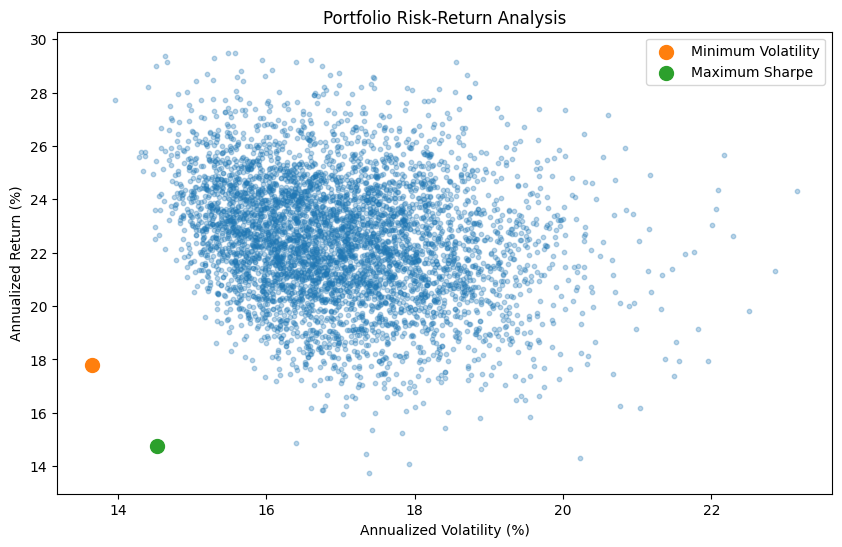

In [ ]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Create a scatter plot of all random portfolios
plt.figure(figsize=(10, 6))

plt.scatter(
    random_portfolios["Volatility"] * 100,
    random_portfolios["Return"] * 100,
    alpha=0.3,
    s=10
)

# Plot the Minimum-Volatility optimized portfolio
plt.scatter(
    min_vol_annualized_volatility * 100,
    min_vol_annualized_return * 100,
    s=100,
    label="Minimum Volatility"
)

# Plot the Maximum-Sharpe optimized portfolio
plt.scatter(
    max_sharpe_annualized_volatility * 100,
    max_sharpe_annualized_return * 100,
    s=100,
    label="Maximum Sharpe"
)

# Add chart labels
plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Return (%)")
plt.title("Portfolio Risk-Return Analysis")

# Display the legend
plt.legend()

# Display the chart
plt.show()

In [ ]:
# Calculate expected return of the Minimum-Volatility portfolio
min_vol_expected_return = np.dot(
    min_vol_weights,
    expected_returns.values
)

# Calculate expected return of the Maximum-Sharpe portfolio
max_sharpe_expected_return = np.dot(
    max_sharpe_weights,
    expected_returns.values
)

# Display the expected returns
print("Minimum-Volatility Portfolio")
print("--------------------------------")
print(
    "Expected Return (%):",
    round(min_vol_expected_return * 100, 2)
)

print("\nMaximum-Sharpe Portfolio")
print("--------------------------------")
print(
    "Expected Return (%):",
    round(max_sharpe_expected_return * 100, 2)
)

# Display their annualized volatilities
print("\nMinimum-Volatility Risk (%):",
      round(portfolio_volatility(min_vol_weights) * 100, 2))

print("Maximum-Sharpe Risk (%):",
      round(portfolio_volatility(max_sharpe_weights) * 100, 2))


Minimum-Volatility Portfolio
--------------------------------
Expected Return (%): 29.42

Maximum-Sharpe Portfolio
--------------------------------
Expected Return (%): 36.7

Minimum-Volatility Risk (%): 13.65
Maximum-Sharpe Risk (%): 14.52


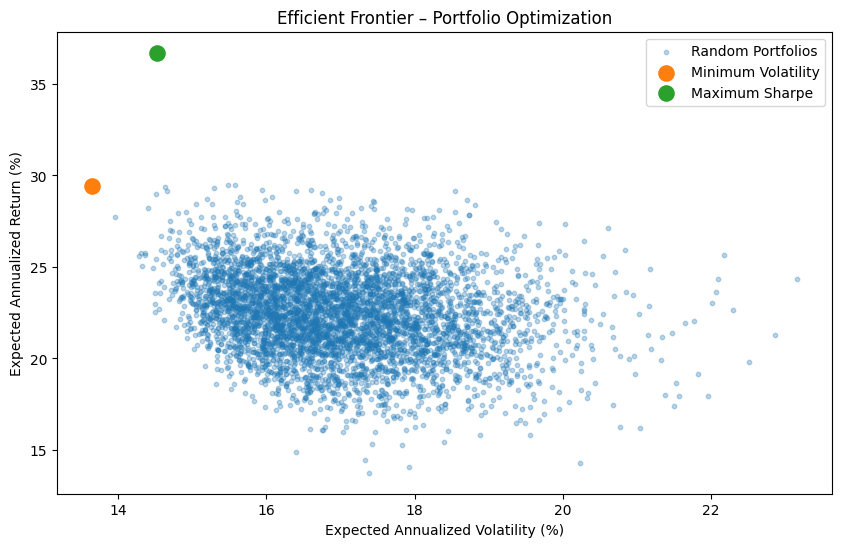

In [ ]:
# Create the efficient frontier visualization
plt.figure(figsize=(10, 6))

# Plot the 5,000 random portfolios
plt.scatter(
    random_portfolios["Volatility"] * 100,
    random_portfolios["Return"] * 100,
    alpha=0.3,
    s=10,
    label="Random Portfolios"
)

# Plot the Minimum-Volatility portfolio
plt.scatter(
    portfolio_volatility(min_vol_weights) * 100,
    min_vol_expected_return * 100,
    s=120,
    label="Minimum Volatility"
)

# Plot the Maximum-Sharpe portfolio
plt.scatter(
    portfolio_volatility(max_sharpe_weights) * 100,
    max_sharpe_expected_return * 100,
    s=120,
    label="Maximum Sharpe"
)

# Add axis labels
plt.xlabel("Expected Annualized Volatility (%)")
plt.ylabel("Expected Annualized Return (%)")

# Add chart title
plt.title("Efficient Frontier – Portfolio Optimization")

# Display legend
plt.legend()

# Display the chart
plt.show()

In [ ]:
# Create a DataFrame showing the stock allocation
# under each portfolio strategy
portfolio_weights = pd.DataFrame({
    "Stock": list(stocks.keys()),

    "Equal Weight (%)": [
        weight * 100
        for weight in weights.values()
    ],

    "Minimum Volatility (%)": [
        weight * 100
        for weight in min_vol_weights
    ],

    "Maximum Sharpe (%)": [
        weight * 100
        for weight in max_sharpe_weights
    ]
})

# Display the portfolio allocation table
print(portfolio_weights.round(2))

                 Stock  Equal Weight (%)  Minimum Volatility (%)  \
0            HDFC Bank              10.0                   20.28   
1  Reliance Industries              10.0                   10.21   
2                  TCS              10.0                   23.81   
3  Mahindra & Mahindra              10.0                    1.50   
4    Adani Enterprises              10.0                    0.00   
5            JSW Steel              10.0                    0.04   
6           Sun Pharma              10.0                   25.52   
7        Bharti Airtel              10.0                   14.69   
8      Larsen & Toubro              10.0                    3.09   
9        Bajaj Finance              10.0                    0.86   

   Maximum Sharpe (%)  
0               31.23  
1                0.00  
2               27.92  
3                0.00  
4                0.00  
5                0.00  
6               40.85  
7                0.00  
8                0.00  
9          

In [ ]:
# Create a summary table for all individual stocks
stock_summary = pd.DataFrame({
    "Stock": list(stocks.keys()),

    # Historical annualized return
    "Annualized Return (%)": [
        expected_returns[stock] * 100
        for stock in stocks.values()
    ],

    # Annualized volatility
    "Annualized Volatility (%)": [
        daily_volatility[stock] * np.sqrt(252) * 100
        for stock in stocks.values()
    ],

    # Maximum drawdown
    "Maximum Drawdown (%)": [
        maximum_drawdown[stock] * 100
        for stock in stocks.values()
    ],

    # CAPM Beta
    "Beta": [
        capm_results[stock].params["Nifty 50"]
        for stock in stocks.values()
    ],

    # CAPM R-squared
    "R-Squared": [
        capm_results[stock].rsquared
        for stock in stocks.values()
    ]
})

# Display the stock-level summary
print(stock_summary.round(2))

                 Stock  Annualized Return (%)  Annualized Volatility (%)  \
0            HDFC Bank                   8.00                      21.24   
1  Reliance Industries                  11.76                      22.73   
2                  TCS                   4.16                      20.76   
3  Mahindra & Mahindra                  39.67                      28.46   
4    Adani Enterprises                  35.55                      49.80   
5            JSW Steel                  25.87                      29.70   
6           Sun Pharma                  24.90                      20.93   
7        Bharti Airtel                  33.65                      22.70   
8      Larsen & Toubro                  27.13                      24.08   
9        Bajaj Finance                  13.80                      28.67   

   Maximum Drawdown (%)  Beta  R-Squared  
0                -23.24  1.05       0.48  
1                -27.18  1.12       0.48  
2                -34.45  0.78     

In [ ]:
# Create a clean dataset for Power BI visualization
powerbi_stock_data = stock_summary.copy()

# Round numerical values for cleaner presentation
powerbi_stock_data = powerbi_stock_data.round(2)

# Display the Power BI-ready stock dataset
print(powerbi_stock_data)

# Check the number of rows and columns
print("\nDataset Shape:", powerbi_stock_data.shape)

                 Stock  Annualized Return (%)  Annualized Volatility (%)  \
0            HDFC Bank                   8.00                      21.24   
1  Reliance Industries                  11.76                      22.73   
2                  TCS                   4.16                      20.76   
3  Mahindra & Mahindra                  39.67                      28.46   
4    Adani Enterprises                  35.55                      49.80   
5            JSW Steel                  25.87                      29.70   
6           Sun Pharma                  24.90                      20.93   
7        Bharti Airtel                  33.65                      22.70   
8      Larsen & Toubro                  27.13                      24.08   
9        Bajaj Finance                  13.80                      28.67   

   Maximum Drawdown (%)  Beta  R-Squared  
0                -23.24  1.05       0.48  
1                -27.18  1.12       0.48  
2                -34.45  0.78     

In [ ]:
# Convert portfolio weights into percentages
portfolio_weights_pct = portfolio_weights.copy()

# Round the allocation values for cleaner presentation
portfolio_weights_pct[
    [
        "Equal Weight (%)",
        "Minimum Volatility (%)",
        "Maximum Sharpe (%)"
    ]
] = portfolio_weights_pct[
    [
        "Equal Weight (%)",
        "Minimum Volatility (%)",
        "Maximum Sharpe (%)"
    ]
].round(2)

# Display the portfolio allocation dataset
print(portfolio_weights_pct)

# Check that each portfolio's weights add up to 100%
print("\nPortfolio Weight Totals:")
print(
    portfolio_weights_pct[
        [
            "Equal Weight (%)",
            "Minimum Volatility (%)",
            "Maximum Sharpe (%)"
        ]
    ].sum()
)

                 Stock  Equal Weight (%)  Minimum Volatility (%)  \
0            HDFC Bank              10.0                   20.28   
1  Reliance Industries              10.0                   10.21   
2                  TCS              10.0                   23.81   
3  Mahindra & Mahindra              10.0                    1.50   
4    Adani Enterprises              10.0                    0.00   
5            JSW Steel              10.0                    0.04   
6           Sun Pharma              10.0                   25.52   
7        Bharti Airtel              10.0                   14.69   
8      Larsen & Toubro              10.0                    3.09   
9        Bajaj Finance              10.0                    0.86   

   Maximum Sharpe (%)  
0               31.23  
1                0.00  
2               27.92  
3                0.00  
4                0.00  
5                0.00  
6               40.85  
7                0.00  
8                0.00  
9          

In [ ]:
# Create a clean portfolio performance dataset
powerbi_portfolio_data = final_portfolio_comparison.copy()

# Round the values for cleaner presentation
powerbi_portfolio_data = powerbi_portfolio_data.round(2)

# Display the Power BI-ready portfolio dataset
print(powerbi_portfolio_data)

# Check the dataset dimensions
print("\nDataset Shape:", powerbi_portfolio_data.shape)

            Portfolio  Annualized Return (%)  Volatility (%)  \
0        Equal Weight                  25.12           16.44   
1  Minimum Volatility                  17.80           13.65   
2      Maximum Sharpe                  14.76           14.52   

   Maximum Drawdown (%)  Sharpe Ratio  Beta  Treynor Ratio  
0                -14.73          1.16  1.08           0.18  
1                -15.23          0.86  0.85           0.14  
2                -17.17          0.60  0.79           0.11  

Dataset Shape: (3, 7)


In [ ]:
# Define the Excel file name
file_name = "Equity_Risk_Portfolio_Analysis.xlsx"

# Create an Excel writer
with pd.ExcelWriter(file_name, engine="openpyxl") as writer:

    # Export stock-level analysis
    powerbi_stock_data.to_excel(
        writer,
        sheet_name="Stock Analysis",
        index=False
    )

    # Export portfolio allocations
    portfolio_weights_pct.to_excel(
        writer,
        sheet_name="Portfolio Weights",
        index=False
    )

    # Export portfolio performance
    powerbi_portfolio_data.to_excel(
        writer,
        sheet_name="Portfolio Performance",
        index=False
    )

# Confirm successful export
print("Excel file created successfully:", file_name)

Excel file created successfully: Equity_Risk_Portfolio_Analysis.xlsx


In [ ]:
# Load the Excel workbook we just created
excel_file = pd.ExcelFile(
    "Equity_Risk_Portfolio_Analysis.xlsx"
)

# Display the sheet names
print("Excel Sheets:")
print(excel_file.sheet_names)

# Read the Stock Analysis sheet
stock_check = pd.read_excel(
    excel_file,
    sheet_name="Stock Analysis"
)

# Read the Portfolio Weights sheet
weights_check = pd.read_excel(
    excel_file,
    sheet_name="Portfolio Weights"
)

# Read the Portfolio Performance sheet
performance_check = pd.read_excel(
    excel_file,
    sheet_name="Portfolio Performance"
)

# Display the dimensions of each sheet
print("\nStock Analysis Shape:", stock_check.shape)
print("Portfolio Weights Shape:", weights_check.shape)
print("Portfolio Performance Shape:", performance_check.shape)

Excel Sheets:
['Stock Analysis', 'Portfolio Weights', 'Portfolio Performance']

Stock Analysis Shape: (10, 6)
Portfolio Weights Shape: (10, 4)
Portfolio Performance Shape: (3, 7)
